# CNN - callbacks - early stopping

En esta Notebook entrenaremos redes neuronales convolucionales (CNN) utilizando el dataset NMIST y empleando callbaks para controlar hasta donde entrenamos y cuando guardamos un modelo en el disco.

***
### Importamos librerías

In [15]:
#Se importan las librerias necesarias
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

from keras.datasets import mnist #cifar10, cifar100
from keras.models import Model
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization #, Activation
from keras.optimizers import Adam #, SGD 
from keras.losses import categorical_crossentropy
from keras.utils import plot_model

In [16]:
#borramos la sesión anterior
keras.backend.clear_session()

***
### Cargamos el dataset

Cargamos el dataset MNIST y realizamos un split de los datos para separar en dos conjuntos: training (60.000 imágenes) y testing (10.000 imágenes).

Las imágenes son del tipo grayscale (escala de gris) de 28x28 pixeles y datos uint8, es decir, números entre 0 y 255.

In [17]:
#cargamos y separamos los datos en dos subconjuntos
(xtrain, ytrain), (xtest, ytest )= mnist.load_data()  #los datos son ndarray



***
### Preprocesado de las imágenes

Redimensionamos los datos para convertirlos en tensores, pasamos de float64 a float32, y normalizamos los datos al intervalo [0,1]. Luego hacemos un split de los datos de entrenamiento para obtener el conjunto de validación. Usaremos la herramienta de sklearn: **train_test_split**

In [18]:
from sklearn.model_selection import train_test_split

#redimensionamos los datos para convertirlos en tensores
xtrain = xtrain.reshape(-1, 28, 28, 1) #agrego una dimensión más porque las imágenes son escala de gris

#hacemos lo mismo con el set de testing
xtest = xtest.reshape(-1, 28, 28,  1) 

#convertimos los datos de float64 a float32 
xtrain = xtrain.astype('float32')
xtest = xtest.astype('float32')

#normalizamos los datos 
xtrain = xtrain/255
x_test = xtest/255

#vamos a separar manualmente los datos de entrenamiento y de validación
# 90% para entrenamiento y 10% para validación
(x_train, x_val, y_train, y_val) = train_test_split(xtrain, ytrain, train_size=0.9)


***
### Seteo hiperparámetros y codifico labeles

Seteamos los hiperparámetros que utilizaremos para el entrenamiento de nuestra CNN, y convertimos las etiquetas a un encoding *1-de-K* usando la función  `keras.utils.to_categorical` 

In [19]:
#hiperparámetros
batch_size = 100  #cantidad de imágenes por batch (lote)
num_classes =10   #10 clases: números que van del 0 al 9
epochs = 15       #cantidad de épocas 

# Convertimos las etiquetas de training y testing a vectores binarios
y_train = keras.utils.to_categorical(y_train, num_classes) 
y_test = keras.utils.to_categorical(ytest, num_classes) 
y_val  = keras.utils.to_categorical(y_val, num_classes) 

In [20]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(54000, 28, 28, 1) (54000, 10)
(6000, 28, 28, 1) (6000, 10)
(10000, 28, 28, 1) (10000, 10)


***
### Defino la arquitectura de la red

Creamos la CNN agregando capas CONV2D, MaxPooling2D, Flatten y Dense. La última capa FC tiene 10 salidas (una por cada clase) y función de activación `softmax`:

In [21]:
#Utilizamos la API funcional:
entradas = Input(shape=(28,28,1)) 
x = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(entradas)
x = MaxPooling2D(pool_size=(2, 2))(x) 
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, 3, activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)  
x = Dense(128, activation='relu')(x)
salida = Dense(num_classes, activation='softmax')(x) 

#Creo el modelo 
modelo = Model(inputs=entradas, outputs=salida)
modelo.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 128)         73856 

***
### Compilamos y entrenamos el modelo

Compilamos el modelo. Cómo usamos one-hot-encoding para codificar las etiquetas, debemos emplear `categorical_crossentropy` como función de pérdida. 
Utilizamos un optimizar `Adam` y la métrica `categorical_accuracy`. 

El comando **fit** me permite ajustar el modelo luego de haberlo compilado. Guardamos el output del método `fit` en la variable `history`, para visualizar la evolución del proceso de entrenamiento.

Para guardar en Drive la arquitectura y los pesos entrenados usaremos un callbacks. Primero debemos montar la cuenta de Gmail (Drive) a Colab.

In [22]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


`NOTAS`:

El callback **ModelCheckpoint** de Keras ofrece varios parámetros que puedes configurar según tus necesidades:

`filepath`: ruta y nombre del archivo donde se guardará el modelo. 

`monitor`: métrica que se utilizará para determinar si se guarda el mejor modelo. Puedes elegir 'val_loss' (pérdida de validación) o 'val_accuracy' (precisión de validación).
    
`save_best_only`: booleano que indica si solo se debe guardar el mejor modelo en función de la métrica de monitoreo. Si está establecido en True, solo se guardará el modelo si mejora con respecto al mejor modelo anterior.

`save_weights_only`: booleano que indica si se deben guardar solo los pesos del modelo en lugar del modelo completo. Si está establecido en True, solo se guardarán los pesos, lo cual puede ser útil si deseas cargar los pesos en un modelo con una arquitectura diferente más tarde.

`mode`: modo para determinar si un valor de métrica es mejor. Puedes elegir entre 'auto', 'min', o 'max'. Por defecto, 'auto' se ajusta automáticamente en función de la métrica de monitoreo.
  
`save_freq`: frecuencia en número de épocas para guardar el modelo. Por ejemplo, si se establece en period=2, el modelo se guardará cada 2 épocas.

Setearemos el callback de la siguiente forma:

**save_best_only=True** asegura que solo se guarde el mejor modelo en función de la val_loss.

**monitor='val_loss'** indica que el callback debe monitorear la val_loss.

**mode='min'** especifica que se debe minimizar la val_loss para determinar el mejor modelo.

**verbose=1** muestra un mensaje cuando se guarda el mejor modelo.

Con esta configuración, se guardará solo el mejor modelo en función de la val_loss en el archivo modeloCNN.h5. 

Debemos proporcionar los datos de validación (x_val y y_val) en el argumento validation_data de modelo.fit() para que se calcule la val_loss y el callback ModelCheckpoint pueda monitorearla y guardar el mejor modelo en función de ese valor.

Observe que a medida que encuentra una val_loss menor, graba el modelo. Puede haber varios modelos guardados para todo el entrenamiento.


In [25]:
modelo.compile(optimizer='adam', loss=categorical_crossentropy, metrics=['categorical_accuracy']) 

#callback configurado con save_best_only=True, garantiza que solo se guarde el mejor modelo según la métrica utilizada para el entrenamiento. No es necesario especificar monitor en este caso.
autoguardado=keras.callbacks.ModelCheckpoint('/content/gdrive/MyDrive/DL/U2/modeloCNN_val_loss_{val_loss:.4f}.h5', monitor='val_loss', save_best_only=True, mode = 'min', verbose = 1)
history = modelo.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_val, y_val), callbacks=[autoguardado], verbose=1)


Epoch 1/15
534/540 [============================>.] - ETA: 0s - loss: 0.0062 - categorical_accuracy: 0.9981
Epoch 1: val_loss improved from inf to 0.06819, saving model to /content/gdrive/MyDrive/DL/U2/modeloCNN_val_loss_0.0682.h5
540/540 [==============================] - 22s 5ms/step - loss: 0.0062 - categorical_accuracy: 0.9981 - val_loss: 0.0682 - val_categorical_accuracy: 0.9860
Epoch 2/15
531/540 [============================>.] - ETA: 0s - loss: 0.0051 - categorical_accuracy: 0.9981
Epoch 2: val_loss improved from 0.06819 to 0.04506, saving model to /content/gdrive/MyDrive/DL/U2/modeloCNN_val_loss_0.0451.h5
540/540 [==============================] - 3s 5ms/step - loss: 0.0050 - categorical_accuracy: 0.9981 - val_loss: 0.0451 - val_categorical_accuracy: 0.9912
Epoch 3/15
538/540 [============================>.] - ETA: 0s - loss: 0.0040 - categorical_accuracy: 0.9988
Epoch 3: val_loss did not improve from 0.04506
540/540 [==============================] - 3s 5ms/step - loss: 0.004

In [31]:
#graficamos la historia del entrenamiento
plt.figure(1)
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train_accu', 'val_accu'], loc='upper left')

plt.figure(2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train_loss','val_loss'], loc='upper left')


KeyError: ignored

<Figure size 640x480 with 0 Axes>

***
### Evaluamos el modelo

Veremos cómo es el comportamiento del modelo sobre los datos de evaluación (testing). Queremos saber si generaliza bien con datos nunca vistos.

In [26]:
test_loss, test_accuracy  = modelo.evaluate(x_test, y_test, verbose = 1)
print(f"Puntuación final: loss {test_loss}, accuracy {test_accuracy}")

313/313 [==============================] - 1s 3ms/step - loss: 0.0507 - categorical_accuracy: 0.9900
Puntuación final: loss 0.05066094174981117, accuracy 0.9900000095367432


**HOMEWORK**:  Probar distintas arquitecturas, número de épocas, batch_size, optimizador, etc y analizar que ocurre.

Utilize la API Secuencial (vea el ejemplo a continuación)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 22, 22, 64)        3200      
                                                                 
 conv2d_1 (Conv2D)           (None, 18, 18, 16)        25616     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 6, 6, 16)         0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 576)               0         
                                                                 
 dense (Dense)               (None, 100)               57700     
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                        

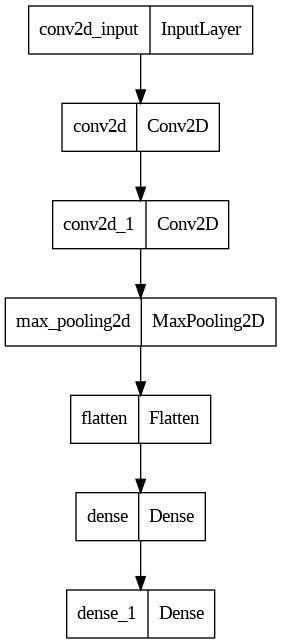

In [27]:
# Ejemplo de uso de la API secuencial: 

# comienzo desde cero (from scratch)
keras.backend.clear_session()

# Modelo secuencial (puede haber ramificaciones)
model = keras.models.Sequential()

# Dos capas Conv, definimos cantidad de filtros y tamaño
model.add(keras.layers.Conv2D(filters=64, kernel_size=7, activation='relu', input_shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(16, 5, activation='relu'))

# Max-Pooling de 3x3
model.add(keras.layers.MaxPooling2D((3, 3)))

# Capa de "achatado". Siempre tiene que ir antes de las capas FC (densas)
model.add(keras.layers.Flatten()) 

# Agregamos una capa densa con 100 neuronas
model.add(keras.layers.Dense(100, activation='relu'))

# Capa de salida con 10 neuronas, activacion softmax
model.add(keras.layers.Dense(10, activation='softmax'))

# # --------------------------------------------------
# # También podemos pasarle una lista de capas:
# model = keras.models.Sequential([
#     keras.layers.Conv2D(filters=64, kernel_size=7, activation='relu', input_shape=(28, 28, 1)),
#     keras.layers.Conv2D(filters=16, kernel_size=5, activation='relu'),
#     keras.layers.MaxPooling2D((3, 3)),
#     keras.layers.Flatten(),
#     keras.layers.Dense(100, activation='relu'),
#     keras.layers.Dense(units=10, activation='softmax')
# ])

model.summary()
keras.utils.plot_model(model)

***
### Early Stopping 

Para acelerar el proceso y verificar que la red no sobreajuste, podemos agregar un `callback` que puede frenar el entrenamiento si no se ven mejorías en la pérdida de validación:

In [28]:
early = keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True)

Esperamos 5 epochs (`patience`) para ver si hay mejoría. Si no hay mejoría, se vuelve a los valores óptimos y se frena el entrenamiento.

Reentrenemos con el callback (pueden implementarse muchos más, vean  `keras.callbacks` y la [documentación](https://keras.io/api/callbacks/).

In [29]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
history = model.fit(epochs=40, batch_size=32, x=x_train, y=y_train, validation_data=(x_val, y_val), callbacks=[early,])

Epoch 1/40
1688/1688 [==============================] - 10s 5ms/step - loss: 0.4422 - accuracy: 0.8695 - val_loss: 0.2023 - val_accuracy: 0.9375
Epoch 2/40
1688/1688 [==============================] - 7s 4ms/step - loss: 0.1273 - accuracy: 0.9618 - val_loss: 0.1071 - val_accuracy: 0.9690
Epoch 3/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0870 - accuracy: 0.9740 - val_loss: 0.0868 - val_accuracy: 0.9747
Epoch 4/40
1688/1688 [==============================] - 8s 4ms/step - loss: 0.0685 - accuracy: 0.9798 - val_loss: 0.0641 - val_accuracy: 0.9815
Epoch 5/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0580 - accuracy: 0.9824 - val_loss: 0.0555 - val_accuracy: 0.9840
Epoch 6/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0501 - accuracy: 0.9846 - val_loss: 0.0541 - val_accuracy: 0.9855
Epoch 7/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0443 - accuracy: 0.9868 - val_loss: 0.0551 - val_accuracy

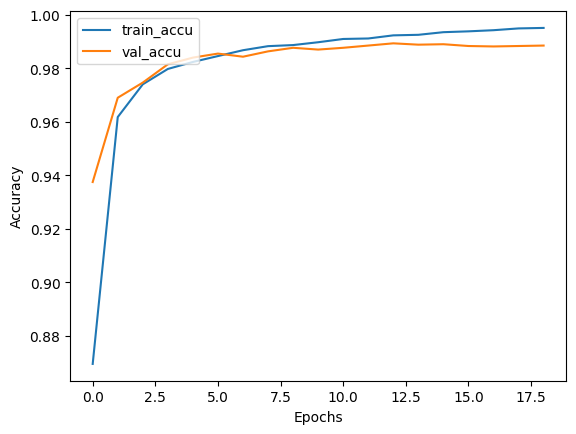

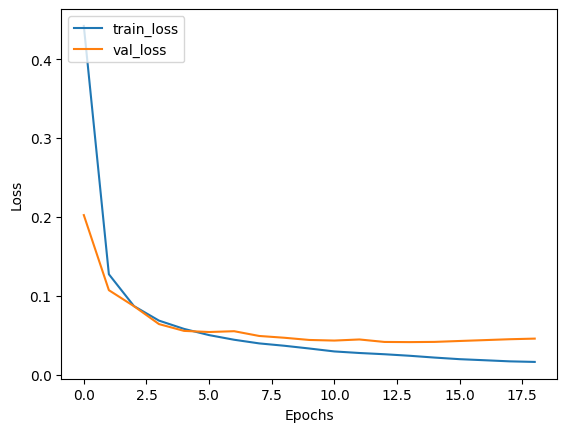

In [32]:
#graficamos la historia del entrenamiento
plt.figure(1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train_accu', 'val_accu'], loc='upper left')

plt.figure(2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train_loss','val_loss'], loc='upper left')
